Importera paket och importera csv-filen med data till en DataFrame

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('health_study_dataset.csv')

## Beskrivande analys

Räkna ut medel, median, min och max för: age, weight, height, systolic_bp, cholesterol.

In [3]:
cols = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']
funcs = ['mean', 'median', 'min', 'max']
units = {
    'age': 'years',
    'weight': 'Kg',
    'height': 'cm',
    'systolic_bp': 'mmHg',
    'cholesterol': 'mmol',
}

df_cols = df[cols].agg(funcs).T.round(1)

df_cols['units'] = df_cols.index.map(units)

df_cols


,mean,median,min,max,units
age,49.4,50.0,18.0,90.0,years
weight,73.4,73.2,33.7,114.4,Kg
height,171.8,171.4,144.4,200.4,cm
systolic_bp,149.2,149.4,106.8,185.9,mmHg
cholesterol,4.9,5.0,2.5,7.9,mmol


Grafer

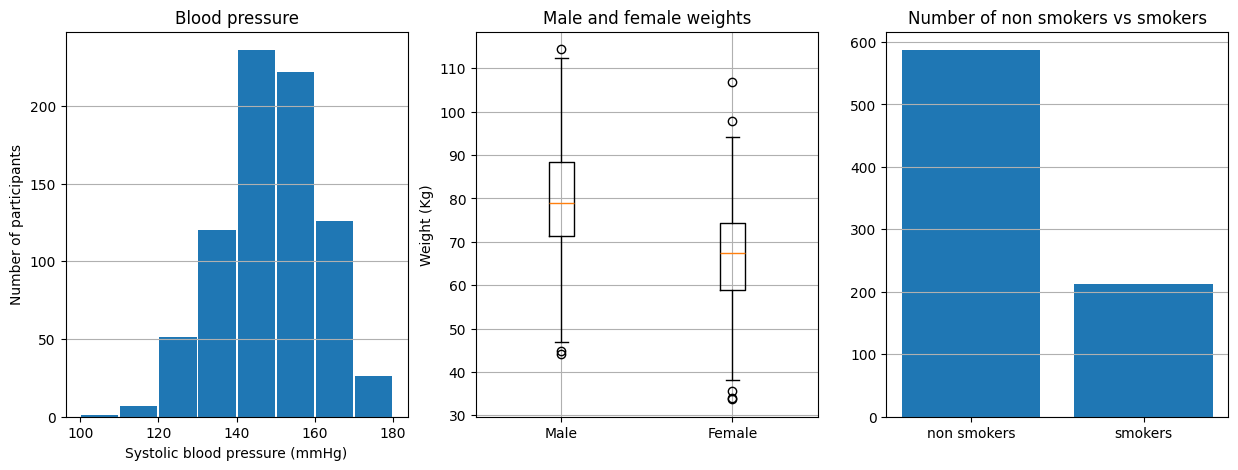

In [4]:
bins = np.arange(100, 190, 10)

fig, (ax_hist, ax_box, ax_bar) = plt.subplots(1,3, figsize=(15,5))

# histogram
ax_hist.hist(df['systolic_bp'], bins=bins, rwidth=0.95)
ax_hist.set_title('Blood pressure')
ax_hist.set_xlabel('Systolic blood pressure (mmHg)')
ax_hist.set_ylabel('Number of participants')
ax_hist.grid(axis='y')

# boxplot
male_box = df[df['sex'] == 'M']['weight']
female_box = df[df['sex'] == 'F']['weight']
ax_box.boxplot([male_box, female_box], tick_labels=['Male', 'Female'])
ax_box.set_title('Male and female weights')
ax_box.grid()
ax_box.set_ylabel('Weight (Kg)')

# barchart
smoker_counts = df['smoker'].value_counts()
ax_bar.bar(['non smokers', 'smokers'], smoker_counts.values)
ax_bar.set_title('Number of non smokers vs smokers')
ax_bar.grid(axis='y')


plt.show()

## Simulering kopplad till caset 
Beräkna andelen personer i datasetet som har sjukdomen.

In [17]:
participants_with_disease = (df['disease'] == 1).mean()

print(f'Percentage of participants with disease: {(participants_with_disease * 100).round(2)} %')

Percentage of participants with disease: 5.88 %


Använd numpy för att simulera 1000 slumpade personer med samma sannolikhet för sjukdom.

In [30]:
np.random.seed(42)

simulated_disease = np.random.choice([0, 1], size=1000, p=[1 - participants_with_disease, participants_with_disease]).mean()

print(f'Percentage of participants with disease: {(simulated_disease * 100).round(2)} %')

Percentage of participants with disease: 5.6 %
